# Feature Description

## Original Dataset Features

| Feature | Type | Description |
|---------|------|-------------|
| `project` | Categorical | Name of the Python project/repository containing the bug (e.g., pandas, keras, scrapy). |
| `bug_id` | Categorical | Unique bug identifier within a project. |
| `python_version` | Categorical | Python version used to reproduce the bug. |
| `buggy_commit_id` | String | Git commit hash corresponding to the buggy version. |
| `fixed_commit_id` | String | Git commit hash corresponding to the bug-fixed version. |
| `test_file` | String | Test file(s) used to reproduce or validate the bug fix. |
| `pythonpath` | String | Optional Python module search path required for certain projects. |
| `patch` | Text | Unified Git diff representing the bug fix. |

## Engineered Features

| Feature | Type | Description | Extraction Logic |
|---------|------|-------------|------------------|
| `modified_files` | List | List of source files modified by the bug fix. | Extracted from `diff --git` headers. |
| `num_files_changed` | Integer | Number of files modified in the patch. | `len(modified_files)` |
| `lines_added` | Integer | Number of added lines of code. | Count lines beginning with `+` (excluding `+++`). |
| `lines_removed` | Integer | Number of removed lines of code. | Count lines beginning with `-` (excluding `---`). |
| `num_hunks` | Integer | Number of contiguous change regions in the patch. | Count occurrences of `@@`. |
| `patch_length` | Integer | Total number of lines in the Git patch, including metadata, context, additions, and deletions. | `len(patch.splitlines())` |
| `has_comment` | Boolean | Indicates whether the patch contains comment syntax. | Regex search for `#`, `//`, `/*`, or `*/`. |
| `declared_classes_in_patch` | List | Class declarations appearing in the patch. | Regex extraction using `class`. |
| `declared_functions_in_patch` | List | Function declarations appearing in the patch. | Regex extraction using `def`. |
| `number_of_declared_classes_in_patch` | Integer | Number of class declarations present in the patch. | `len(declared_classes_in_patch)` |
| `number_of_declared_functions_in_patch` | Integer | Number of function declarations present in the patch. | `len(declared_functions_in_patch)` |

> **Note:** `declared_classes_in_patch` and `declared_functions_in_patch` count declarations appearing anywhere within the Git patch. Since Git patches include surrounding context lines, these features represent the structural scope of the patch rather than the exact number of modified class or function definitions.

In [73]:
import streamlit as st
import pandas as pd
from sqlalchemy import create_engine
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Two Ways to Connect to PostgreSQL

In [74]:
engine = create_engine('postgresql+psycopg2://krishnapriyagitalaxmi@localhost:5432/bugsinpy')
test = pd.read_sql("SELECT * FROM bug_dataset LIMIT 5", engine)
test

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,patch_length,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules
0,keras,32,3.7.3,a3d160b9467c99cbb27f9aa0382c759f45c8ee66,709f791af201caaab4aa180bda259989087cfe47,tests/keras/test_callbacks.py,diff --git a/keras/callbacks.py b/keras/callba...,None,{keras/callbacks.py},1,...,66,False,"{ReduceLROnPlateau,ReduceLROnPlateau,ReduceLRO...","{__init__,in_cooldown}",5,2,{ValueError},1,{keras},1
1,keras,35,3.7.3,06eaeebecfb73c23bfd531013ca172ee3bf5069c,738819de0b7e6bc45abed8d0640f02b81c6ac4e9,tests/keras/preprocessing/image_test.py,diff --git a/keras/preprocessing/image.py b/ke...,None,{keras/preprocessing/image.py},1,...,45,True,"{ImageDataGenerator,NumpyArrayIterator,Directo...",{},3,0,{ValueError},1,{keras/preprocessing},1
2,keras,34,3.7.3,7ef5244a2f1f7f7b76e3c804b82cbb20cdf4d139,4b74fc5418944c9f449eb88ed4b40ada280fa5ca,tests/test_multiprocessing.py,diff --git a/keras/engine/training.py b/keras/...,None,"{keras/engine/training.py,keras/utils/data_uti...",2,...,69,True,"{Model,Model,Model,Model,Sequence}",{__iter__},5,1,{},0,"{keras/engine,keras/utils}",2
3,keras,33,3.7.3,1c9a49781da2101507db23e2014e4e5d16bd2e52,70ad0d6e4a569701ef106058397ad0540ec08340,tests/keras/preprocessing/text_test.py,diff --git a/keras/preprocessing/text.py b/ker...,None,{keras/preprocessing/text.py},1,...,30,False,{},{text_to_word_sequence},0,1,{},0,{keras/preprocessing},1
4,keras,20,3.7.3,76da5f0a21ca98e4bf6706e182fb825243e76204,6dd087ab73b09e449144ff17450cc14f981b9ac2,tests/keras/layers/convolutional_test.py,diff --git a/keras/backend/cntk_backend.py b/k...,None,"{keras/backend/cntk_backend.py,keras/backend/t...",5,...,236,True,"{Conv2DTranspose,Conv2DTranspose,Conv2DTranspo...","{in_top_k,conv2d_transpose,conv2d_transpose,_p...",5,22,{ValueError},1,"{keras/backend,keras/layers,keras/utils}",3


In [75]:
conn = psycopg2.connect(
    host="localhost",
    database="bugsinpy",
    user="krishnapriyagitalaxmi")
cursor = conn.cursor()
cursor.execute("SELECT * FROM bug_dataset LIMIT 5")
rows = cursor.fetchall()
rows

[('keras',
  '32',
  '3.7.3',
  'a3d160b9467c99cbb27f9aa0382c759f45c8ee66',
  '709f791af201caaab4aa180bda259989087cfe47',
  'tests/keras/test_callbacks.py',
  'diff --git a/keras/callbacks.py b/keras/callbacks.py\nindex 8b5ec5f3..eb233de3 100644\n--- a/keras/callbacks.py\n+++ b/keras/callbacks.py\n@@ -898,7 +898,7 @@ class ReduceLROnPlateau(Callback):\n             monitored has stopped increasing; in `auto`\n             mode, the direction is automatically inferred\n             from the name of the monitored quantity.\n-        epsilon: threshold for measuring the new optimum,\n+        min_delta: threshold for measuring the new optimum,\n             to only focus on significant changes.\n         cooldown: number of epochs to wait before resuming\n             normal operation after lr has been reduced.\n@@ -906,16 +906,21 @@ class ReduceLROnPlateau(Callback):\n     """\n \n     def __init__(self, monitor=\'val_loss\', factor=0.1, patience=10,\n-                 verbose=0, mode=\'

In [76]:
cursor.close()
conn.close()

EDA - Exploratory Data Analysis 

In [77]:
#import data from database
df_raw=pd.read_sql("SELECT * FROM bug_dataset", engine)
df_raw.head(10)

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,patch_length,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules
0,keras,32,3.7.3,a3d160b9467c99cbb27f9aa0382c759f45c8ee66,709f791af201caaab4aa180bda259989087cfe47,tests/keras/test_callbacks.py,diff --git a/keras/callbacks.py b/keras/callba...,NaN,{keras/callbacks.py},1,...,66,False,"{ReduceLROnPlateau,ReduceLROnPlateau,ReduceLRO...","{__init__,in_cooldown}",5,2,{ValueError},1,{keras},1
1,keras,35,3.7.3,06eaeebecfb73c23bfd531013ca172ee3bf5069c,738819de0b7e6bc45abed8d0640f02b81c6ac4e9,tests/keras/preprocessing/image_test.py,diff --git a/keras/preprocessing/image.py b/ke...,NaN,{keras/preprocessing/image.py},1,...,45,True,"{ImageDataGenerator,NumpyArrayIterator,Directo...",{},3,0,{ValueError},1,{keras/preprocessing},1
2,keras,34,3.7.3,7ef5244a2f1f7f7b76e3c804b82cbb20cdf4d139,4b74fc5418944c9f449eb88ed4b40ada280fa5ca,tests/test_multiprocessing.py,diff --git a/keras/engine/training.py b/keras/...,NaN,"{keras/engine/training.py,keras/utils/data_uti...",2,...,69,True,"{Model,Model,Model,Model,Sequence}",{__iter__},5,1,{},0,"{keras/engine,keras/utils}",2
3,keras,33,3.7.3,1c9a49781da2101507db23e2014e4e5d16bd2e52,70ad0d6e4a569701ef106058397ad0540ec08340,tests/keras/preprocessing/text_test.py,diff --git a/keras/preprocessing/text.py b/ker...,NaN,{keras/preprocessing/text.py},1,...,30,False,{},{text_to_word_sequence},0,1,{},0,{keras/preprocessing},1
4,keras,20,3.7.3,76da5f0a21ca98e4bf6706e182fb825243e76204,6dd087ab73b09e449144ff17450cc14f981b9ac2,tests/keras/layers/convolutional_test.py,diff --git a/keras/backend/cntk_backend.py b/k...,NaN,"{keras/backend/cntk_backend.py,keras/backend/t...",5,...,236,True,"{Conv2DTranspose,Conv2DTranspose,Conv2DTranspo...","{in_top_k,conv2d_transpose,conv2d_transpose,_p...",5,22,{ValueError},1,"{keras/backend,keras/layers,keras/utils}",3
5,keras,16,3.7.3,514aca20c6f076a86819d7180f36c3b2e8bcc33b,fe38f9dfc8c732a77ac03507b63c79b1d2acfba2,tests/keras/test_sequential_model.py,diff --git a/keras/engine/sequential.py b/kera...,NaN,{keras/engine/sequential.py},1,...,59,True,"{Sequential,Sequential,Sequential}","{__init__,get_config,from_config}",3,3,{},0,{keras/engine},1
6,keras,18,3.7.3,9400be98783135a1d42dd238f4e6c3aa048eceea,244546c2fe5165b6770eb456afd5fac8878473c5,tests/keras/backend/backend_test.py,diff --git a/keras/backend/tensorflow_backend....,NaN,{keras/backend/tensorflow_backend.py},1,...,55,True,"{Function,Function,Function,Function}",{_legacy_call},4,1,{ValueError},1,{keras/backend},1
7,keras,27,3.7.3,49f5b931410bc2e56378f20a15e8ac919e0efb88,b076e227da6beaf87d6c84eff1a92285e4662acf,tests/keras/layers/wrappers_test.py,diff --git a/keras/layers/wrappers.py b/keras/...,NaN,{keras/layers/wrappers.py},1,...,29,False,{Bidirectional},"{get_updates_for,losses,get_losses_for,constra...",1,4,{},0,{keras/layers},1
8,keras,9,3.7.3,0cd3b07eb5de1aaaad84d1ff7f7c2ed7dab4b23c,0505393746d56ddacc34bb1c016dba79429c9ac9,tests/test_doc_auto_generation.py,diff --git a/docs/autogen.py b/docs/autogen.py...,NaN,{docs/autogen.py},1,...,15,True,{},"{count_leading_spaces,process_list_block}",0,2,{},0,{docs},1
9,keras,11,3.7.3,36b9e4c055f32718a036cabaf767325b010c7485,d6b5c5ebb410e3366c9d7aca41977a60134bfe10,tests/integration_tests/test_image_data_tasks.py,diff --git a/keras/engine/training_generator.p...,NaN,"{keras/engine/training_generator.py,keras/engi...",5,...,224,True,{Sequence},"{fit_generator,fit_generator,fit_generator,fit...",1,15,{ValueError},1,"{keras/engine,keras/utils,tests,tests/keras/ut...",4


In [78]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   project                                501 non-null    str  
 1   bug_id                                 501 non-null    str  
 2   python_version                         501 non-null    str  
 3   buggy_commit_id                        501 non-null    str  
 4   fixed_commit_id                        501 non-null    str  
 5   test_file                              501 non-null    str  
 6   patch                                  501 non-null    str  
 7   pythonpath                             49 non-null     str  
 8   modified_files                         501 non-null    str  
 9   num_files_changed                      501 non-null    int64
 10  lines_added                            501 non-null    int64
 11  lines_removed                          501 

Observed nulls in pythonpath column - need to investigate further

In [79]:
df_raw[df_raw["pythonpath"].notnull()]["project"].value_counts()

project
ansible         18
tornado         16
tqdm             9
cookiecutter     4
keras            2
Name: count, dtype: int64

In [80]:
df_raw[df_raw["pythonpath"].isnull()]["project"].value_counts()

project
pandas        169
keras          43
youtube-dl     43
scrapy         40
luigi          33
thefuck        32
matplotlib     30
black          23
fastapi        16
spacy          10
sanic           5
httpie          5
PySnooper       3
Name: count, dtype: int64

Pythonpath is populated for a small subset of bugs. It appears to be optional execution metadata rather than an analytical feature, so missing values are expected and were left unchanged

In [81]:
df_raw.describe(include='number')

,num_files_changed,lines_added,lines_removed,num_hunks,patch_length,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,num_exception_types,num_modified_modules
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,1.291417,15.385230,15.592814,4.850299,56.518962,1.634731,3.025948,0.473054,1.181637
std,0.814191,62.517208,124.970356,7.467499,208.857009,3.915650,11.266647,1.079709,0.548582
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,2.000000,15.000000,0.000000,0.000000,0.000000,1.000000
50%,1.000000,4.000000,2.000000,2.000000,23.000000,1.000000,1.000000,0.000000,1.000000
75%,1.000000,11.000000,4.000000,4.000000,40.000000,2.000000,2.000000,1.000000,1.000000
max,8.000000,764.000000,1578.000000,120.000000,2612.000000,68.000000,135.000000,10.000000,6.000000


Observed min =0 in all raws depicting some row/rows have no patch information attached to it

In [82]:
df_raw[df_raw['num_files_changed']==0]

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,patch_length,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules
38,keras,12,3.7.3,6dff721a3a8755356b2e89d02ef63ad8ab38ec95,6dff721a3a8755356b2e89d02ef63ad8ab38ec95,tests/keras/metrics_test.py,,NaN,{},0,...,0,False,{},{},0,0,{},0,{},0


One bug instance (keras, bug 12) contained an empty bug_patch.txt. Since this project analyzes source code patches and all engineered patch features depend on the patch content, this record will be excluded from downstream analysis. (Cleaning will be handled together)

In [83]:
df_raw[df_raw['num_files_changed']==8]

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,patch_length,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules
107,scrapy,33,3.8.3,2d216771976cd7aedfb88ae97418c2d4dcc84917,6dccb3a9b320a8d0808764ac8e6e88e663e2d52c,tests/test_pipeline_media.py;tests/test_utils_...,diff --git a/scrapy/core/engine.py b/scrapy/co...,NaN,"{scrapy/core/engine.py,scrapy/core/scraper.py,...",8,...,430,True,"{ExecutionEngine,ExecutionEngine,ExecutionEngi...","{_handle_downloader_output,spider_is_idle,log_...",15,19,{},0,"{scrapy,scrapy/core,scrapy/downloadermiddlewar...",6


In [84]:
df_raw[df_raw['lines_added']==764]

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,patch_length,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules
399,pandas,17,3.8.3,1e5ff23,afb04645b5b3361814f7d00ef68ce8d68e19ddb8,pandas/tests/indexes/datetimes/test_insert.py,diff --git a/pandas/core/arrays/datetimelike.p...,NaN,"{pandas/core/arrays/datetimelike.py,pandas/tes...",3,...,2612,True,"{InvalidComparison,AttributesMixin,DatetimeInd...","{_datetimelike_array_cmp,_validate_comparison_...",15,135,"{AbstractMethodError,AmbiguousTimeError,Incomp...",10,"{pandas/core/arrays,pandas/tests/indexing}",2


In [85]:
df_raw.describe(include='string')

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,declared_classes_in_patch,declared_functions_in_patch,exception_types,modified_modules
count,501,501,501,501,501,501,501,49,501,501,501,501,501
unique,17,169,7,498,501,319,501,4,301,266,319,56,142
top,pandas,1,3.8.3,e21a31162f4c54be693d8ca8260e42393b39abd3,709f791af201caaab4aa180bda259989087cfe47,test/test_utils.py,diff --git a/keras/callbacks.py b/keras/callba...,,{youtube_dl/utils.py},{},{},{},{youtube_dl}
freq,169,17,287,2,1,31,1,18,24,169,152,352,31


In [86]:
df_raw[df_raw['lines_added']==0]

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,patch_length,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules
34,keras,23,3.7.3,3dcd9c767ce6875fc8b69c74971ac8a552e23131,69c30a150f0b2caee7961ca1c0080960ef5ad6f6,tests/keras/test_sequential_model.py,diff --git a/keras/engine/sequential.py b/kera...,NaN,{keras/engine/sequential.py},1,...,13,False,{Sequential},{},1,0,{},0,{keras/engine},1
38,keras,12,3.7.3,6dff721a3a8755356b2e89d02ef63ad8ab38ec95,6dff721a3a8755356b2e89d02ef63ad8ab38ec95,tests/keras/metrics_test.py,,NaN,{},0,...,0,False,{},{},0,0,{},0,{},0
88,luigi,29,3.8.3,07efdd9136966ffe143ea57e15b1a57b5698fd5a,2898a2d2d178499435892d7a69bb1dfc90c70b29,test/task_test.py,diff --git a/luigi/task_register.py b/luigi/ta...,NaN,"{luigi/task_register.py,test/cmdline_test.py}",2,...,47,True,"{Register,AmbiguousClass,NonAmbiguousClass,Non...","{run,run,test_cmdline_ambiguous_class,test_cmd...",6,5,{},0,"{luigi,test}",2
336,pandas,95,3.8.3,036dc88,c99dfea33612f44e97c2365f78c0ca6d5754a1bc,pandas/tests/arithmetic/test_period.py,diff --git a/pandas/core/arrays/period.py b/pa...,NaN,{pandas/core/arrays/period.py},1,...,24,True,{},"{_period_array_cmp,wrapper,_period_array_cmp}",0,3,{ValueError},1,{pandas/core/arrays},1
403,pandas,19,3.8.3,17dc6b0,c6a1638bcd99df677a8f76f036c0b30027eb243c,pandas/tests/indexing/multiindex/test_loc.py;p...,diff --git a/pandas/core/indexing.py b/pandas/...,NaN,{pandas/core/indexing.py},1,...,42,True,{_LocIndexer},{},1,0,{NotImplementedError},1,{pandas/core},1
406,pandas,8,3.8.3,ddbeca6,d09f20e29bdfa82f5efc071986e2633001d552f6,pandas/tests/frame/methods/test_replace.py,diff --git a/pandas/core/internals/blocks.py b...,NaN,{pandas/core/internals/blocks.py},1,...,16,True,{Block},{},1,0,{},0,{pandas/core/internals},1


In [87]:
df_raw[df_raw['lines_removed']==0]

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,patch_length,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules
7,keras,27,3.7.3,49f5b931410bc2e56378f20a15e8ac919e0efb88,b076e227da6beaf87d6c84eff1a92285e4662acf,tests/keras/layers/wrappers_test.py,diff --git a/keras/layers/wrappers.py b/keras/...,NaN,{keras/layers/wrappers.py},1,...,29,False,{Bidirectional},"{get_updates_for,losses,get_losses_for,constra...",1,4,{},0,{keras/layers},1
23,keras,44,3.7.3,cc08f0f01fe97a9659e3da8fa9b290a54992c74a,3292aa5a30350c67627f173ceac713956f68271f,tests/keras/layers/recurrent_test.py,diff --git a/keras/layers/recurrent.py b/keras...,NaN,{keras/layers/recurrent.py},1,...,22,False,"{RNN,RNN}","{trainable_weights,non_trainable_weights}",2,2,{},0,{keras/layers},1
24,keras,43,3.7.3,e3e97c401aa8251e957b73fba8ed4d108c106f12,b17169ca5d6cd1c8aeb237fc2bb0555c9e1b6a02,tests/keras/utils/np_utils_test.py,diff --git a/keras/utils/np_utils.py b/keras/u...,NaN,{keras/utils/np_utils.py},1,...,13,False,{},{to_categorical},0,1,{},0,{keras/utils},1
38,keras,12,3.7.3,6dff721a3a8755356b2e89d02ef63ad8ab38ec95,6dff721a3a8755356b2e89d02ef63ad8ab38ec95,tests/keras/metrics_test.py,,NaN,{},0,...,0,False,{},{},0,0,{},0,{},0
40,keras,2,3.7.3,2f55055a9f053b35fa721d3eb75dd07ea5a5f1e3,c24d16af155e20976bdf61e468ba760408e676ff,tests/keras/backend/backend_test.py,diff --git a/keras/backend/numpy_backend.py b/...,,{keras/backend/numpy_backend.py},1,...,17,False,{},"{l2_normalize,in_top_k,binary_crossentropy}",0,3,{},0,{keras/backend},1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,pandas,85,3.8.3,f1aaf62,29edd119d31a9ee7d4f89e8c1dc8af96f0c19dce,pandas/tests/groupby/test_apply.py,diff --git a/pandas/core/indexes/multi.py b/pa...,NaN,{pandas/core/indexes/multi.py},1,...,15,True,{MultiIndex},{},1,0,{},0,{pandas/core/indexes},1
481,pandas,71,3.8.3,74a5edc,a5daff22e6e37af4946c614f85b110905e063be3,pandas/tests/arrays/test_integer.py,diff --git a/pandas/core/reshape/tile.py b/pan...,NaN,{pandas/core/reshape/tile.py},1,...,27,True,{},{cut},0,1,{ValueError},1,{pandas/core/reshape},1
482,pandas,125,3.8.3,e639af2,fb08ceeeeba2ba62f92b47d424b3ae83c20ed9db,pandas/tests/arrays/categorical/test_algos.py;...,diff --git a/pandas/core/arrays/categorical.py...,NaN,"{pandas/core/arrays/categorical.py,pandas/core...",2,...,91,True,"{Categorical,CategoricalBlock}","{replace,replace}",2,2,{},0,"{pandas/core/arrays,pandas/core/internals}",2
485,pandas,49,3.8.3,113c255,37659d47a685ecc5f5117aa56526ece0106c6d0f,pandas/tests/test_strings.py,diff --git a/pandas/core/strings.py b/pandas/c...,NaN,{pandas/core/strings.py},1,...,13,False,{},"{str_repeat,rep}",0,2,{TypeError},1,{pandas/core},1


In [88]:
df_clean=df_raw[~((df_raw['bug_id']=="12") & (df_raw['project']=='keras'))]
df_clean.describe(include='number')

,num_files_changed,lines_added,lines_removed,num_hunks,patch_length,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,num_exception_types,num_modified_modules
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1.294000,15.416000,15.624000,4.860000,56.632000,1.638000,3.032000,0.474000,1.184000
std,0.812949,62.576021,125.093563,7.471817,209.050839,3.918886,11.277115,1.080583,0.546572
min,1.000000,0.000000,0.000000,2.000000,10.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,2.000000,1.000000,2.000000,15.000000,0.000000,0.000000,0.000000,1.000000
50%,1.000000,4.000000,2.000000,2.000000,23.000000,1.000000,1.000000,0.000000,1.000000
75%,1.000000,11.000000,4.000000,4.000000,40.000000,2.000000,2.000000,1.000000,1.000000
max,8.000000,764.000000,1578.000000,120.000000,2612.000000,68.000000,135.000000,10.000000,6.000000


Data Coverage Investigation

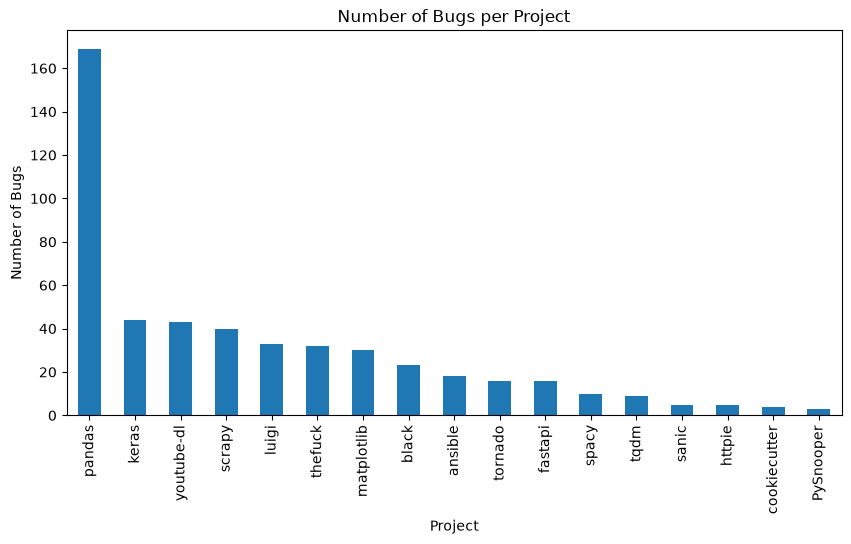

In [89]:
%matplotlib inline
df_projectwise_bugs=df_clean["project"].value_counts().sort_values(ascending=False)
df_projectwise_bugs.plot(kind='bar', figsize=(10, 5))
plt.title("Number of Bugs per Project")
plt.xlabel("Project")  
plt.ylabel("Number of Bugs")
plt.show()

The BugsInPy dataset exhibits an uneven distribution of bug instances across projects. Pandas contributes the largest number of bugs (169), while several projects contribute fewer than 10. 

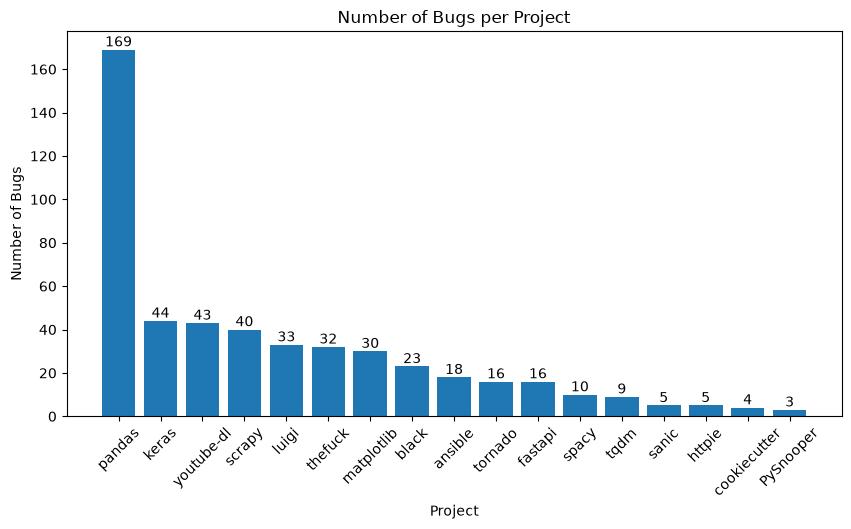

In [90]:
plt.figure(figsize=(10, 5))
bar = plt.bar(df_projectwise_bugs.index, df_projectwise_bugs.values)
plt.title("Number of Bugs per Project")
plt.xlabel("Project")
plt.ylabel("Number of Bugs")
plt.xticks(rotation=45)
plt.bar_label(bar)
plt.show()


* High coverage: pandas, keras, scrapy
* Low coverage: PySnooper, sanic

Issues this could cause , can be investigated later:
eg: if pandas patches are generally larger than FastAPI patches, the model might partly learn “this looks like a pandas bug.” 


In [91]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 0 to 500
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   project                                500 non-null    str  
 1   bug_id                                 500 non-null    str  
 2   python_version                         500 non-null    str  
 3   buggy_commit_id                        500 non-null    str  
 4   fixed_commit_id                        500 non-null    str  
 5   test_file                              500 non-null    str  
 6   patch                                  500 non-null    str  
 7   pythonpath                             49 non-null     str  
 8   modified_files                         500 non-null    str  
 9   num_files_changed                      500 non-null    int64
 10  lines_added                            500 non-null    int64
 11  lines_removed                          500 non-n

## What do bug patches generally look line BugsinPy?

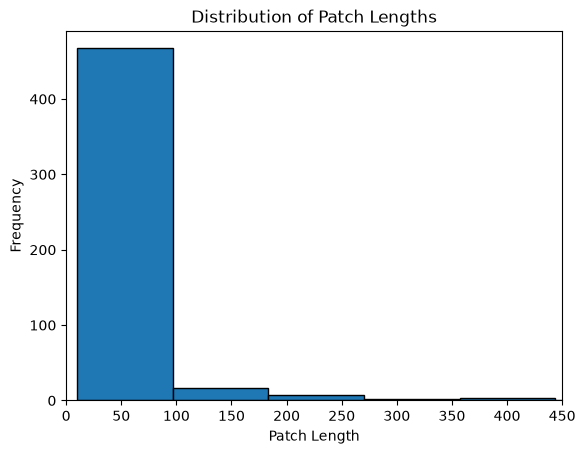

In [92]:
plt.hist(df_clean['patch_length'], bins=30, edgecolor='black')
plt.title("Distribution of Patch Lengths")
plt.xlabel("Patch Length")
plt.ylabel("Frequency")
plt.xlim(0,450)
plt.show()

In [93]:
df_clean[['patch_length', 'num_files_changed']].describe(include='number', percentiles=[.25, .5, .75, .9, .95, .99])

,patch_length,num_files_changed
count,500.000000,500.000000
mean,56.632000,1.294000
std,209.050839,0.812949
min,10.000000,1.000000
25%,15.000000,1.000000
50%,23.000000,1.000000
75%,40.000000,1.000000
90%,78.100000,2.000000
95%,116.600000,3.000000
99%,432.550000,5.000000


* The distribution is strongly **right-skewed**, indicating that most bug fixes involve relatively small patches.

* The **median patch length is 23**, meaning half of all bug fixes have a patch length of 23 or less.

* The **75th percentile is 40**, suggesting that most bug fixes remain relatively small.

* A small number of patches are substantially larger, producing a long right tail and indicating the presence of outliers.

suggesting that bug fixes in the BugsInPy dataset seem generally localized (The fix is confined to a small part of the codebase rather than spread across many files or many sections of code.), with only a few requiring extensive code modifications.

## How much code is typically modiefied to fix a bug?

## Code Churn Analysis

(0.0, 240.0)

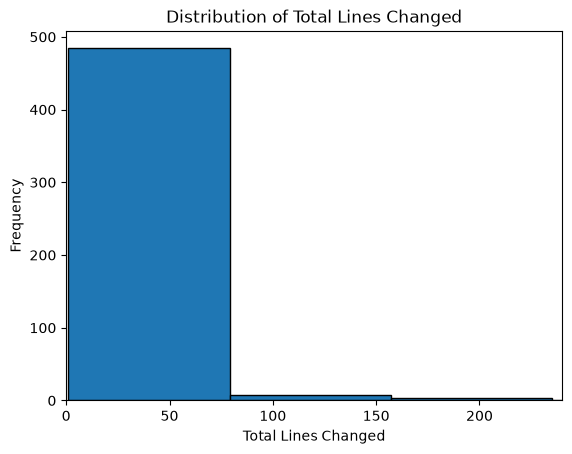

In [94]:
total_lines_changed= df_clean["lines_added"] + df_clean["lines_removed"]
total_lines_changed.plot(kind='hist', bins=30, edgecolor='black')
plt.title("Distribution of Total Lines Changed")
plt.xlabel("Total Lines Changed")
plt.ylabel("Frequency")
plt.xlim(0,240)

In [95]:
total_lines_changed.describe(percentiles=[.25, .5, .75, .9, .95, .99])

count     500.000000
mean       31.040000
std       185.883457
min         1.000000
25%         4.000000
50%         7.000000
75%        16.000000
90%        35.100000
95%        62.050000
99%       235.030000
max      2342.000000
dtype: float64

/var/folders/7z/3cdlrtxd6535vwnb4277r5tc0000gn/T/ipykernel_18306/1896496242.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(total_lines_changed, vert=False)


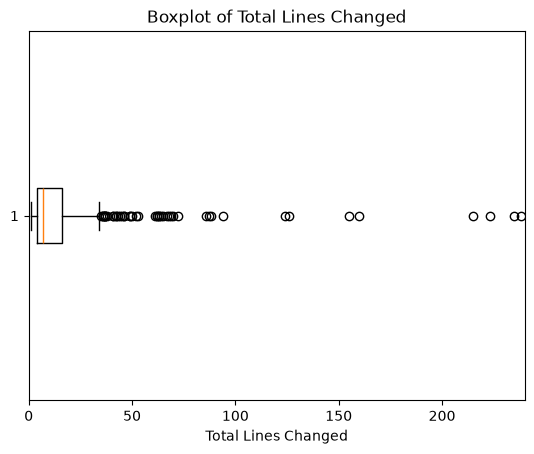

In [96]:
plt.boxplot(total_lines_changed, vert=False)
plt.title("Boxplot of Total Lines Changed")
plt.xlabel("Total Lines Changed")
plt.xlim(0, 240)
plt.show()

The distribution of total lines changed is highly right-skewed. While the mean bug fix modifies approximately 31 lines of code, the median is only 7 lines, indicating that most bug fixes are relatively small. The boxplot reveals numerous high-value outliers, suggesting that a small number of complex bugs require substantially larger code modifications.

We are seeing the same pattern twice:

* patch_length is right-skewed
* total_lines_changed is right-skewed

Are these two features strongly correlated?

In [97]:
df_clean['lines_changed'] = df_clean['lines_added'] + df_clean['lines_removed']
df_clean.head()

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules,lines_changed
0,keras,32,3.7.3,a3d160b9467c99cbb27f9aa0382c759f45c8ee66,709f791af201caaab4aa180bda259989087cfe47,tests/keras/test_callbacks.py,diff --git a/keras/callbacks.py b/keras/callba...,NaN,{keras/callbacks.py},1,...,False,"{ReduceLROnPlateau,ReduceLROnPlateau,ReduceLRO...","{__init__,in_cooldown}",5,2,{ValueError},1,{keras},1,17
1,keras,35,3.7.3,06eaeebecfb73c23bfd531013ca172ee3bf5069c,738819de0b7e6bc45abed8d0640f02b81c6ac4e9,tests/keras/preprocessing/image_test.py,diff --git a/keras/preprocessing/image.py b/ke...,NaN,{keras/preprocessing/image.py},1,...,True,"{ImageDataGenerator,NumpyArrayIterator,Directo...",{},3,0,{ValueError},1,{keras/preprocessing},1,19
2,keras,34,3.7.3,7ef5244a2f1f7f7b76e3c804b82cbb20cdf4d139,4b74fc5418944c9f449eb88ed4b40ada280fa5ca,tests/test_multiprocessing.py,diff --git a/keras/engine/training.py b/keras/...,NaN,"{keras/engine/training.py,keras/utils/data_uti...",2,...,True,"{Model,Model,Model,Model,Sequence}",{__iter__},5,1,{},0,"{keras/engine,keras/utils}",2,26
3,keras,33,3.7.3,1c9a49781da2101507db23e2014e4e5d16bd2e52,70ad0d6e4a569701ef106058397ad0540ec08340,tests/keras/preprocessing/text_test.py,diff --git a/keras/preprocessing/text.py b/ker...,NaN,{keras/preprocessing/text.py},1,...,False,{},{text_to_word_sequence},0,1,{},0,{keras/preprocessing},1,17
4,keras,20,3.7.3,76da5f0a21ca98e4bf6706e182fb825243e76204,6dd087ab73b09e449144ff17450cc14f981b9ac2,tests/keras/layers/convolutional_test.py,diff --git a/keras/backend/cntk_backend.py b/k...,NaN,"{keras/backend/cntk_backend.py,keras/backend/t...",5,...,True,"{Conv2DTranspose,Conv2DTranspose,Conv2DTranspo...","{in_top_k,conv2d_transpose,conv2d_transpose,_p...",5,22,{ValueError},1,"{keras/backend,keras/layers,keras/utils}",3,67


## Correlation Analysis between Numerical features

<Axes: >

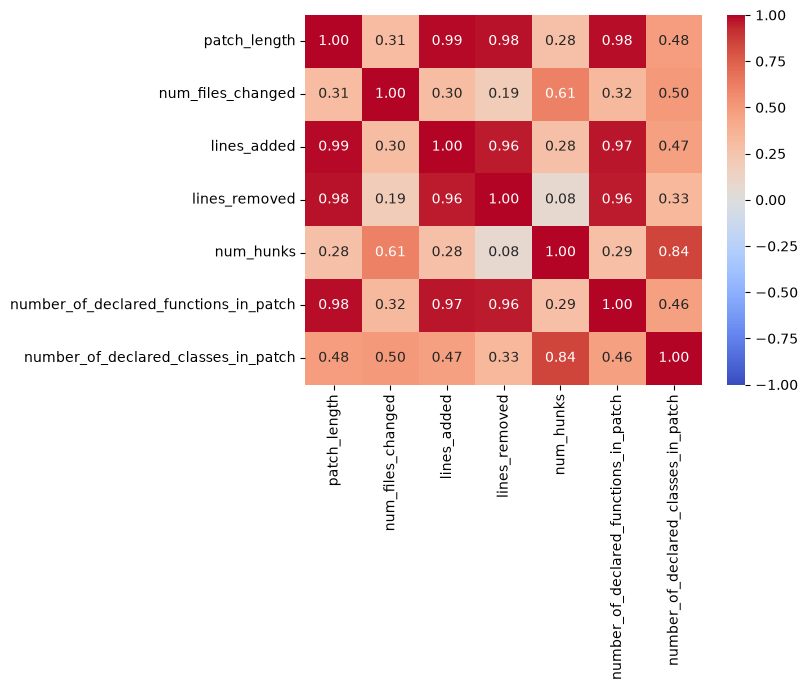

In [98]:
correlation_matrix = df_clean[['patch_length', 'num_files_changed', 'lines_added', 'lines_removed','num_hunks','number_of_declared_functions_in_patch','number_of_declared_classes_in_patch']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

The strongest cluster:

patch_length - lines_added                     0.99

patch_length - lines_removed                   0.98

patch_length - declared_functions              0.98

lines_added - declared_functions               0.97

lines_removed - declared_functions             0.96

Larger patches tend to modify more lines of code and involve more function definitions or declarations.

Some weak correlations:

num_files_changed - patch_length    0.31

num_files_changed - lines_added     0.30

num_files_changed - lines_removed   0.19

A large bug fix does not necessarily span many files.

A moderate-to-strong relationship:

num_hunks - num_files_changed = 0.61

A hunk is one contiguous block of changes.If you modify more files,you’ll usually have more hunks.

num_hunks - declared_classes = 0.84

Bug fixes touching many classes also tend to be spread across multiple change regions.


Almost no correlation:

num_hunks - lines_removed = 0.08

Removing lots of lines doesn’t necessarily create many hunks.

## Which Python versions are represented in BugsInPy?

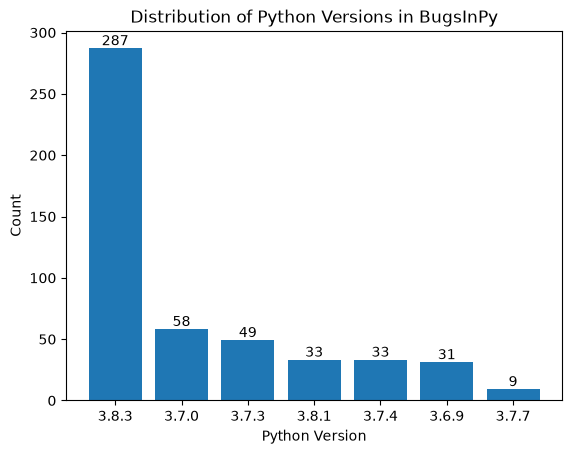

In [99]:
python_version_counts = df_clean['python_version'].value_counts()
bar=plt.bar(python_version_counts.index, python_version_counts.values)
plt.xlabel('Python Version')
plt.ylabel('Count')
plt.title('Distribution of Python Versions in BugsInPy')
plt.bar_label(bar)
plt.show()

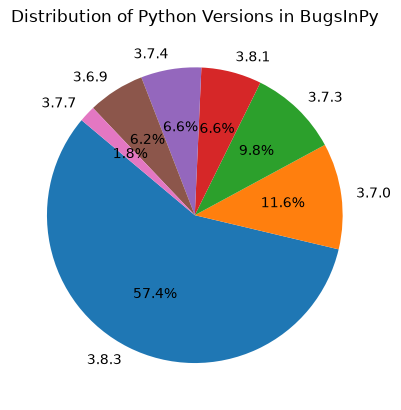

In [100]:
plt.pie(python_version_counts.values, labels=python_version_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Python Versions in BugsInPy')
plt.show()

* Python 3.8.3 dominates the dataset, accounting for well over half of all bug instances.
* The remaining bugs are distributed across several versions of Python 3.6, 3.7, and 3.8.
* The dataset spans multiple Python releases, indicating that BugsInPy is not tied to a single runtime environment and contains bugs reproduced under different interpreter versions.
* Some Python versions (e.g., 3.7.7) are represented by only a handful of bugs, suggesting that version-specific analyses for these releases may not be statistically meaningful.

## How frequently do bug-fix patches contain comments?

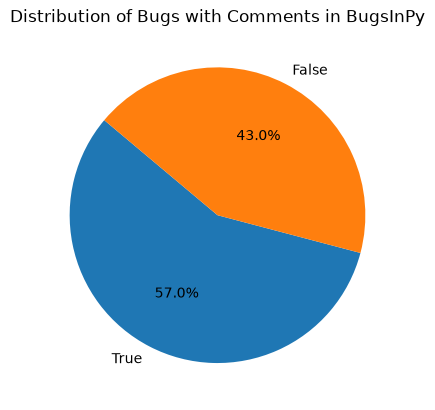

In [101]:
has_comments_counts = df_clean['has_comment'].value_counts()
plt.pie(has_comments_counts.values, labels=has_comments_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Bugs with Comments in BugsInPy')
plt.show()

* 57% of bug-fix patches contain at least one comment.
* 43% do not contain any detected comments.
* This suggests that comments frequently accompany bug fixes, either to explain implementation decisions, document behavior, or update existing documentation.
* However, since the distribution is fairly balanced, the presence of comments alone is unlikely to be a strong feature for the machine learning model .

## Project-wise Analysis

## Which projects tend to have larger bug fix patches?

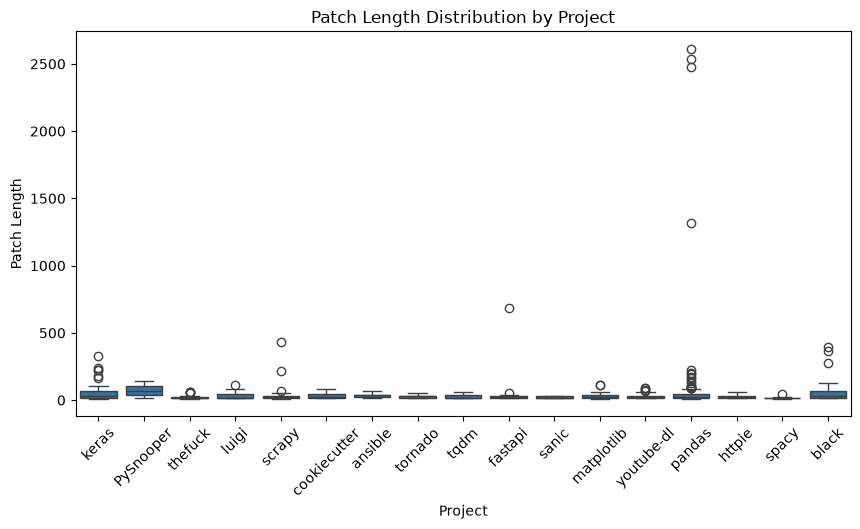

In [102]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='project', y='patch_length', data=df_clean)
plt.xticks(rotation=45)
plt.title('Patch Length Distribution by Project')
plt.xlabel('Project')
plt.ylabel('Patch Length')
plt.show()


Pandas has a few 2500-line patches that stretch the y-axis.

As a result, every other box gets compressed near zero.

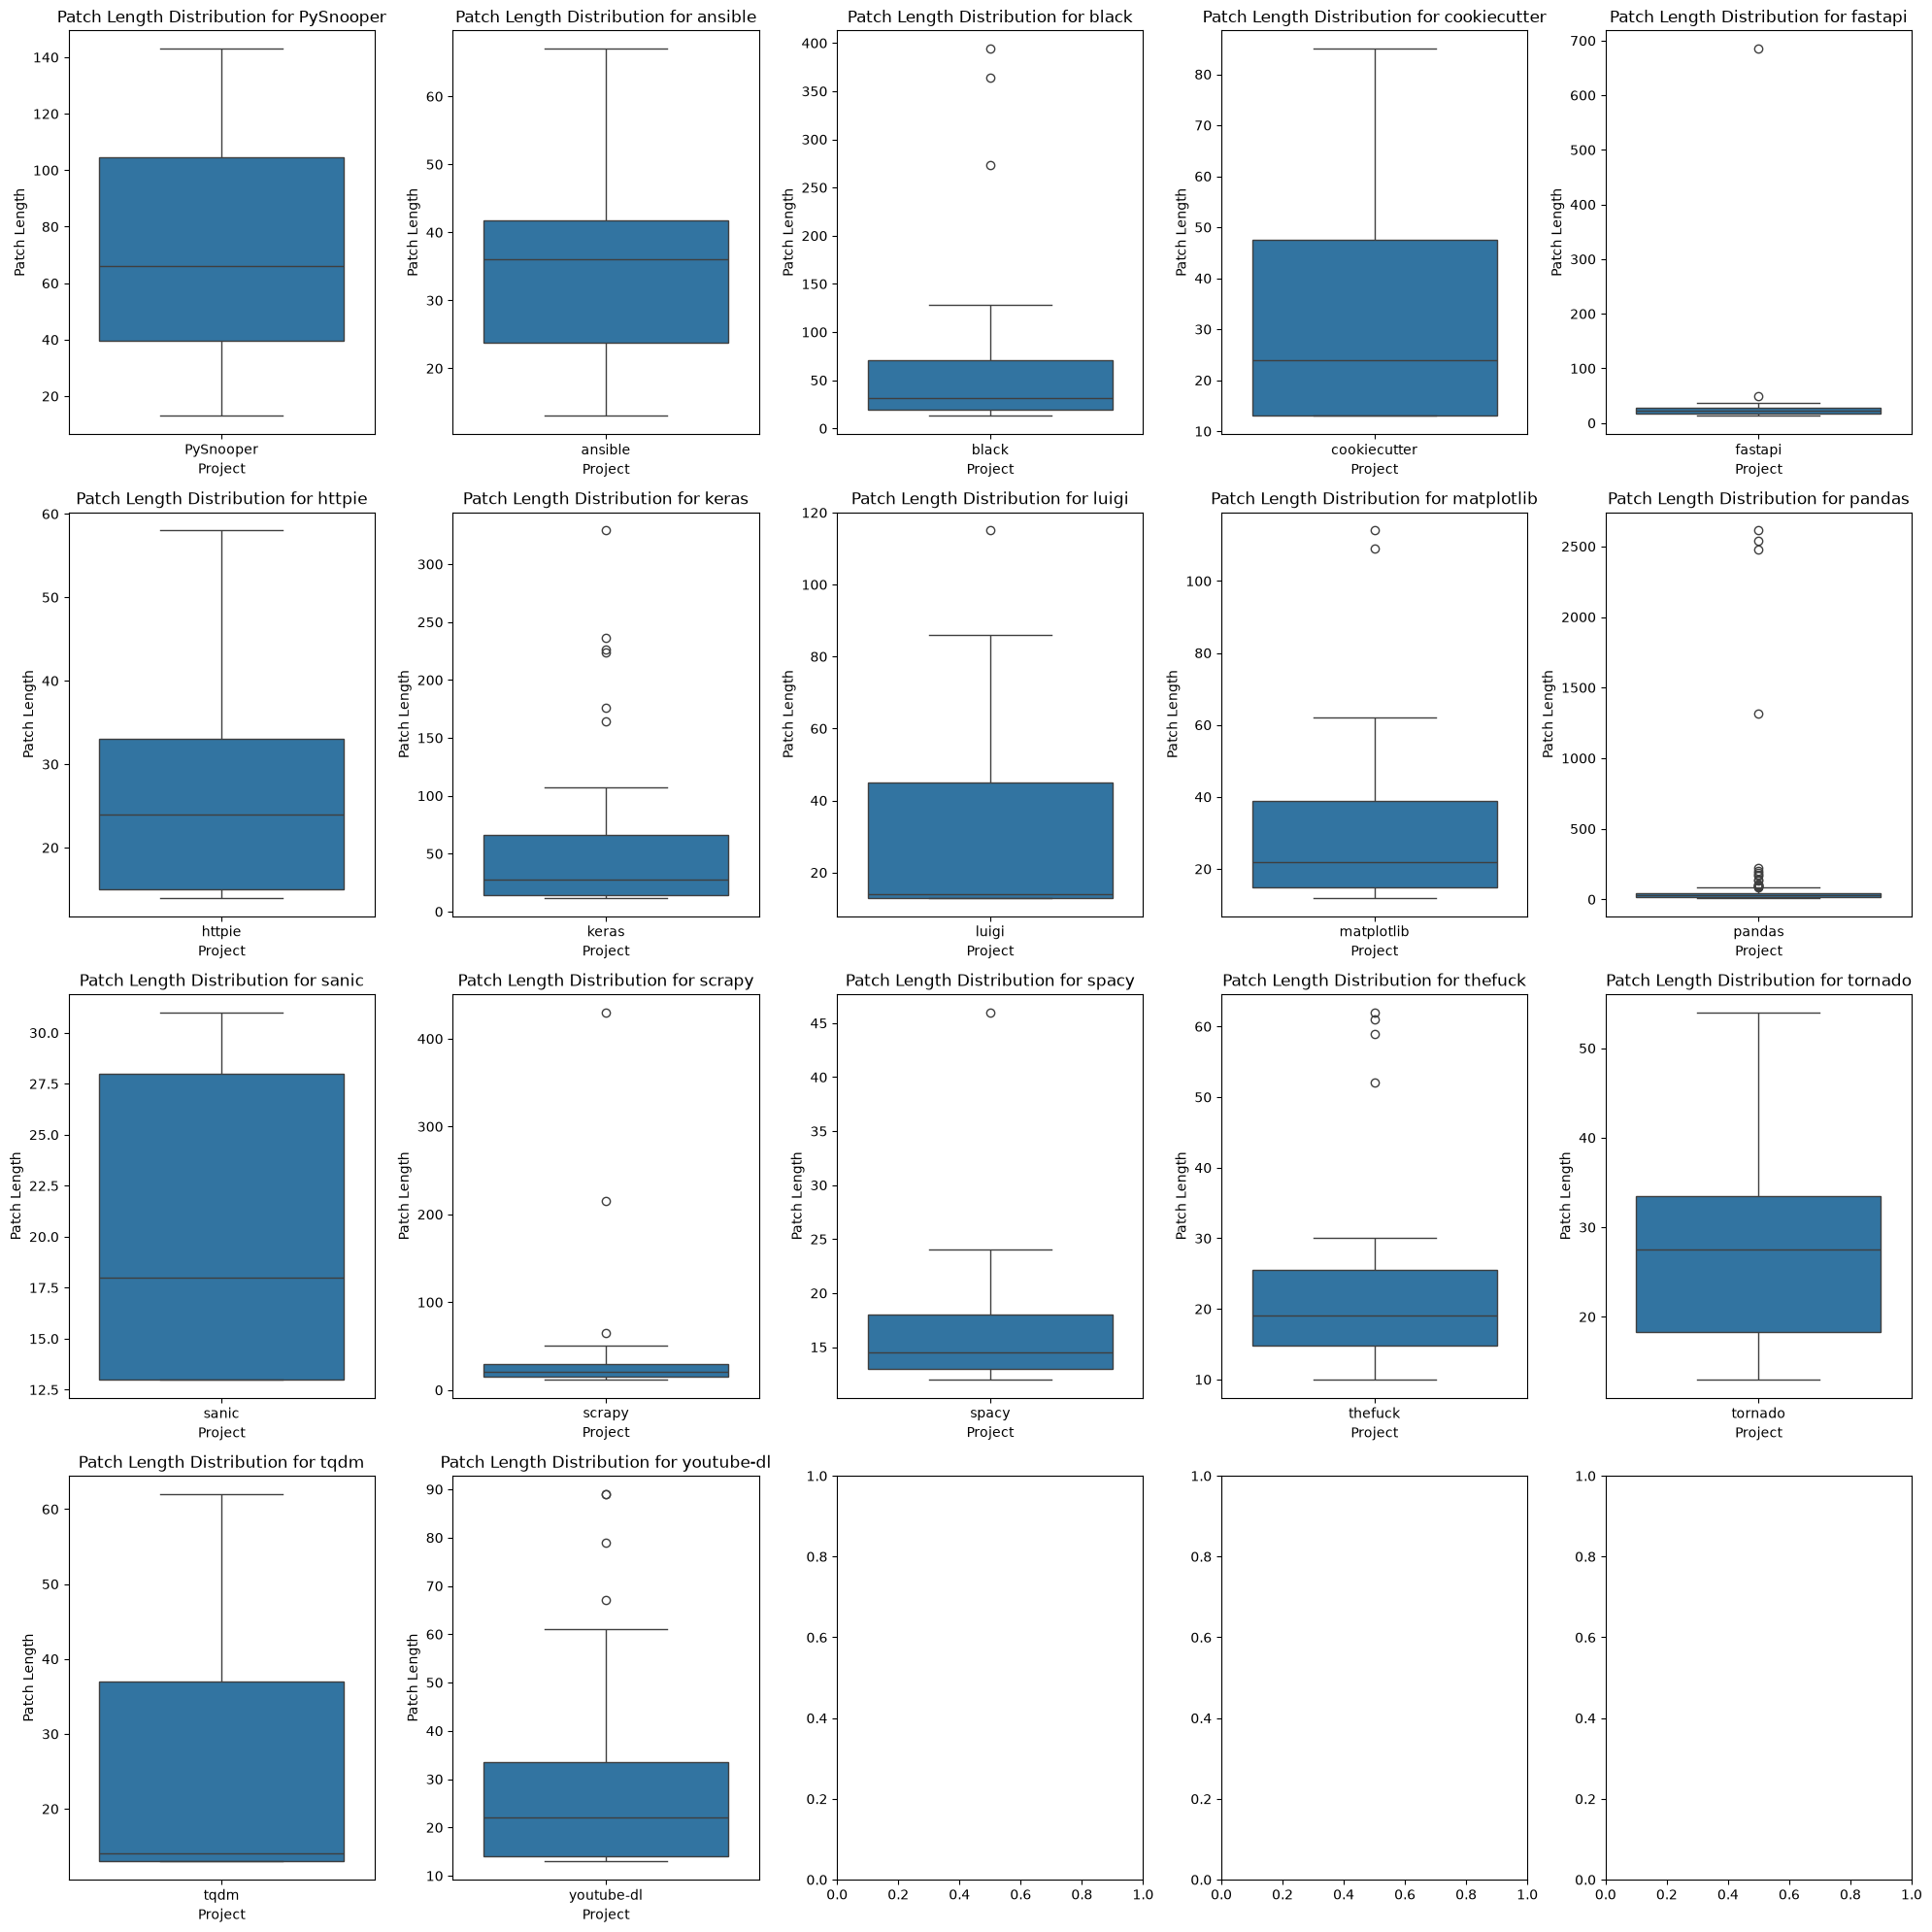

In [103]:
projects=sorted(df_clean['project'].unique())
fig,axes = plt.subplots(nrows=4, ncols=5, figsize=(20,20))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easier iteration
for i, project in enumerate(projects):
    sns.boxplot(x='project', y='patch_length', data=df_clean[df_clean['project']==project], ax=axes[i])
    axes[i].set_title(f'Patch Length Distribution for {project}')
    axes[i].set_xlabel('Project')
    axes[i].set_ylabel('Patch Length')
plt.tight_layout()

Pandas contains the most extreme bug fixes

* Median patch length is still relatively small.
* However, it contains several extremely large outliers, including patches exceeding 2500 lines.

Although most pandas bug fixes are comparable in size to other projects, a small number of exceptionally large fixes substantially increase the overall variability.

Text(0, 0.5, 'Patch Length')

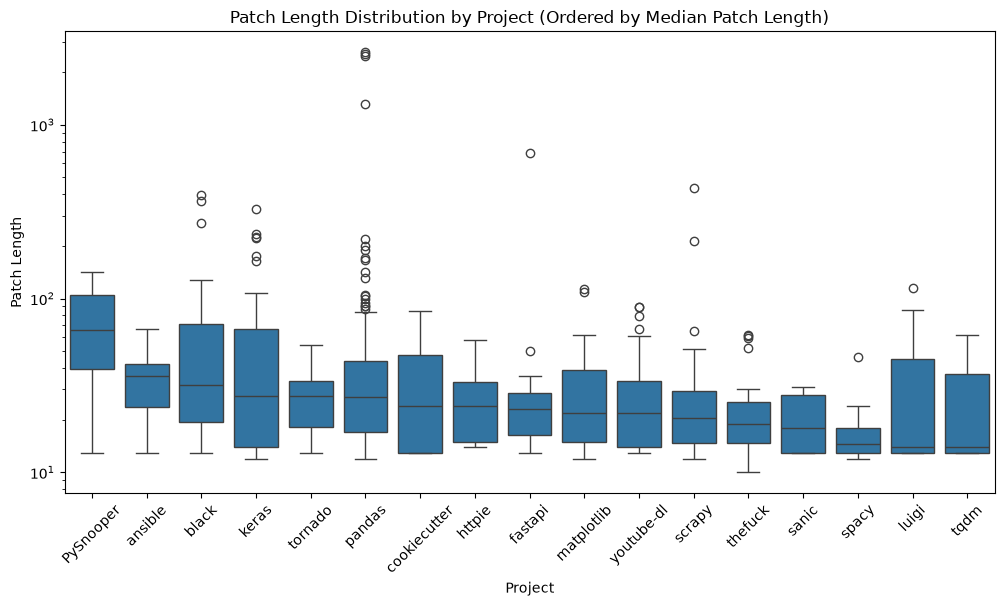

In [104]:
order = df_clean.groupby('project')['patch_length'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='project', y='patch_length', data=df_clean, order=order)
plt.xticks(rotation=45)
plt.title('Patch Length Distribution by Project (Ordered by Median Patch Length)')
plt.xlabel('Project')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.ylabel('Patch Length')  


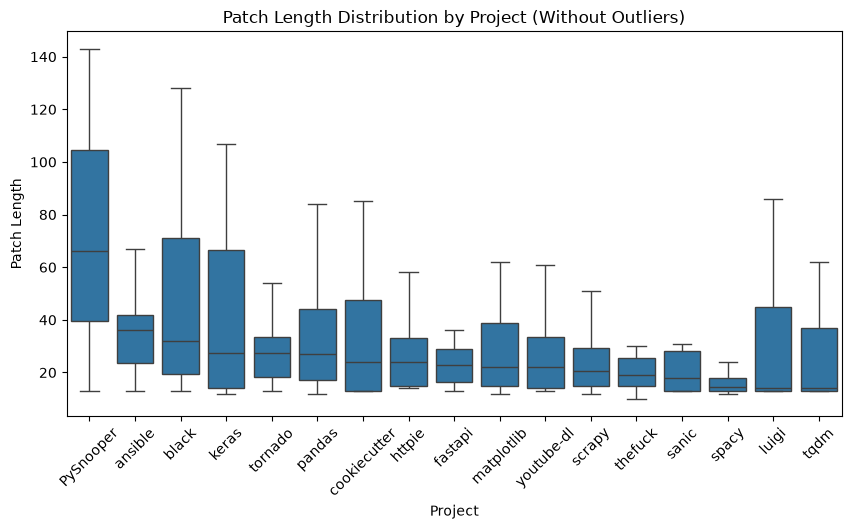

In [105]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='project', y='patch_length', data=df_clean,order=order, showfliers=False)
plt.xticks(rotation=45)
plt.title('Patch Length Distribution by Project (Without Outliers)')
plt.xlabel('Project')
plt.ylabel('Patch Length')
plt.show()

Two complementary visualizations are presented: one excluding outliers to facilitate comparison of the central distributions, and another using a logarithmic scale to visualize the complete range of patch lengths, including extreme observations.

Despite the diversity of projects, the median patch length for most repositories lies between approximately 15 and 35 lines. This suggests that the majority of bug fixes involve relatively localized code modifications rather than extensive refactoring.

Among the repositories, PySnooper exhibits the highest median patch length and a comparatively wide interquartile range, indicating that, within this dataset, its bug fixes generally involve larger code modifications than those of other projects.

Projects such as Black, Keras, Pandas, and Luigi exhibit relatively large interquartile ranges, indicating greater variability in patch lengths within these repositories. While many bug fixes remain small, these projects also contain a wider range of bug-fix sizes than the other repositories.

## Do projects differ in the amount of code they actually modify to fix a bug?

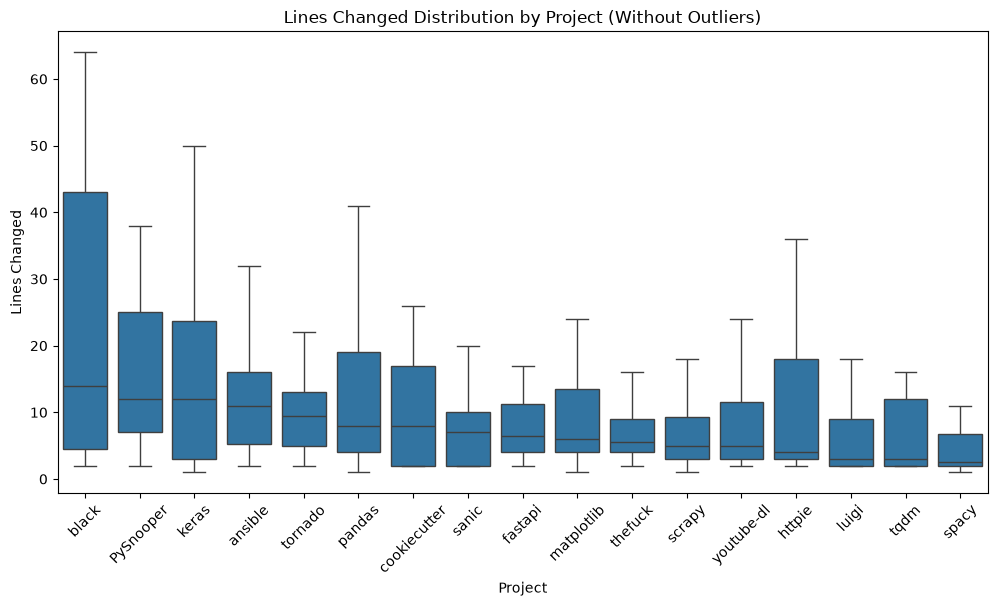

In [106]:
order = df_clean.groupby('project')['lines_changed'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='project', y='lines_changed', data=df_clean, order=order,showfliers=False)
plt.xticks(rotation=45)
plt.title('Lines Changed Distribution by Project (Without Outliers)')
plt.xlabel('Project')
plt.ylabel('Lines Changed')
plt.show()

Across most repositories, the median number of lines changed remains below 15 lines, indicating that the majority of bug fixes require relatively localized code changes.

Black, PySnooper, and Keras exhibit the largest typical code changes.These repositories have the highest median values and comparatively wide interquartile ranges, suggesting that their bug fixes generally involve modifying more lines of code than those of other repositories within this dataset.

Repositories such as Black, Keras, Pandas, HTTPie, and PySnooper display relatively large interquartile ranges, indicating that the amount of code modified varies substantially between bug fixes.

Projects including spaCy, Luigi,and Scrapy have comparatively compact distributions, suggesting that their bug fixes tend to involve smaller and more consistent code modifications.


* In the patch-length plot, PySnooper was clearly the largest.
* Here, Black actually has the highest median code churn.

A larger Git patch does not necessarily correspond to more lines of code being modified.


## Semantic Feature Analysis

## What are the top exception types?

In [107]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 0 to 500
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   project                                500 non-null    str  
 1   bug_id                                 500 non-null    str  
 2   python_version                         500 non-null    str  
 3   buggy_commit_id                        500 non-null    str  
 4   fixed_commit_id                        500 non-null    str  
 5   test_file                              500 non-null    str  
 6   patch                                  500 non-null    str  
 7   pythonpath                             49 non-null     str  
 8   modified_files                         500 non-null    str  
 9   num_files_changed                      500 non-null    int64
 10  lines_added                            500 non-null    int64
 11  lines_removed                          500 non-n

In [109]:
from collections import Counter

exception_counts= Counter(exception for exception_list in df_clean["exception_types"] for exception in exception_list)

exception_counts

Counter({'r': 733,
         '{': 500,
         '}': 500,
         'o': 309,
         'e': 269,
         'E': 247,
         't': 122,
         'a': 113,
         'l': 113,
         'u': 105,
         ',': 88,
         'n': 85,
         'V': 74,
         'p': 74,
         'i': 64,
         'y': 59,
         'T': 55,
         'm': 52,
         'd': 48,
         'I': 38,
         'c': 37,
         'x': 35,
         's': 33,
         'b': 21,
         'A': 21,
         'N': 19,
         'K': 17,
         'P': 11,
         'M': 11,
         'v': 11,
         'g': 9,
         'O': 9,
         'k': 8,
         'R': 8,
         'w': 8,
         'U': 7,
         'F': 7,
         'h': 7,
         'q': 7,
         'H': 6,
         'f': 6,
         'D': 5,
         'L': 4,
         'C': 4,
         'S': 3,
         'J': 2,
         'Z': 1})

In [110]:
type(df_clean["exception_types"].iloc[0])

str

In [111]:
df_clean["exception_types"] = df_clean["exception_types"].apply(
    lambda x: [] if x == "{}" else x.strip("{}").split(",")
)

In [112]:
exception_counts= Counter(exception for exception_list in df_clean["exception_types"] for exception in exception_list)

exception_counts

Counter({'ValueError': 72,
         'TypeError': 36,
         'KeyError': 16,
         'NotImplementedError': 12,
         'IndexError': 7,
         'ImportError': 6,
         'AttributeError': 6,
         'AbstractMethodError': 6,
         'OverflowError': 6,
         'RuntimeError': 5,
         'ExtractorError': 5,
         'InvalidIndexError': 4,
         'AnsibleError': 3,
         'HTTPException': 3,
         'MergeError': 3,
         'AmbiguousTimeError': 3,
         'NonExistentTimeError': 3,
         'NullFrequencyError': 3,
         'LookupError': 2,
         'UnicodeError': 2,
         'URLError': 2,
         'OSError': 2,
         'ParseError': 2,
         'AssertionError': 2,
         'DateParseError': 2,
         'IncompatibleFrequencyError': 2,
         'TaskClassException': 1,
         'UnknownParameterException': 1,
         'MissingParameterException': 1,
         'HadoopJarJobError': 1,
         'ContextDecodingException': 1,
         'CookiecutterException': 1,
     

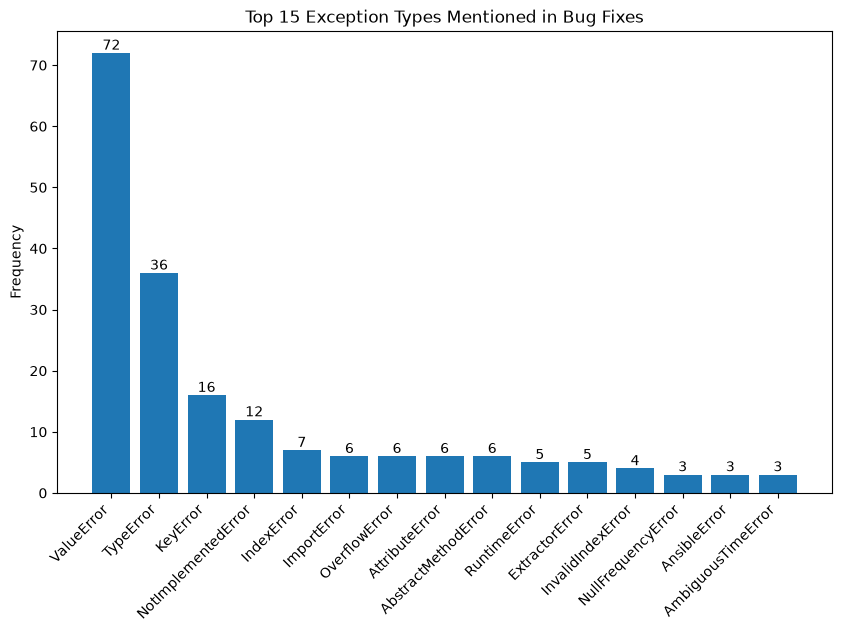

In [121]:
top_exceptions = (pd.Series(exception_counts).sort_values(ascending=False).head(15))
plt.figure(figsize=(10,6))
bars=plt.bar(top_exceptions.index,top_exceptions.values)
plt.bar_label(bars)
plt.ylabel("Frequency")
plt.xticks(rotation=45,ha="right")
plt.title("Top 15 Exception Types Mentioned in Bug Fixes")
plt.show()

ValueError is the most frequently referenced exception type, appearing in 72 bug-fix patches. This is expected, as it is commonly used in Python libraries to signal invalid inputs or parameter values.

The distribution is highly skewed. ValueError, TypeError, KeyError, and NotImplementedError occur substantially more often than the remaining exception types, indicating that a relatively small set of exception classes accounts for a large proportion of bug fixes.

project-specific exception classes such as ExtractorError, InvalidIndexError, and AbstractMethodError. This shows that the feature captures repository-specific semantics alongside generic Python exceptions.

Most exception types appear only a few times, suggesting a long-tailed distribution in which many specialized exceptions are associated with only a small number of bug fixes.

## Which are the Top Modified Modules?

In [123]:
#Convert back to lists
df_clean["modified_modules"] = df_clean["modified_modules"].apply(
    lambda x:
    [] if x == "{}"
    else [m.strip() for m in x.strip("{}").split(",")]
    )

df_clean["modified_modules"]


0                                         [keras]
1                           [keras/preprocessing]
2                     [keras/engine, keras/utils]
3                           [keras/preprocessing]
4      [keras/backend, keras/layers, keras/utils]
                          ...                    
496                         [pandas/core/groupby]
497    [pandas/core/ops, pandas/tests/arithmetic]
498                          [pandas/core/window]
499                                   [pandas/io]
500                          [pandas/core/arrays]
Name: modified_modules, Length: 500, dtype: object

In [125]:
module_counts= Counter( 
    module
    for module_list in df_clean["modified_modules"]
    for module in module_list
    )
module_counts

Counter({'youtube_dl': 40,
         'pandas/core': 40,
         'pandas/core/indexes': 32,
         'pandas/core/arrays': 26,
         'luigi': 25,
         'thefuck/rules': 22,
         '.': 22,
         'lib/matplotlib': 18,
         'pandas/core/reshape': 18,
         'tornado': 16,
         'pandas/core/groupby': 15,
         'pandas/core/internals': 13,
         'keras/engine': 12,
         'scrapy': 11,
         'keras': 10,
         'scrapy/utils': 10,
         'fastapi': 10,
         'lib/matplotlib/axes': 10,
         'youtube_dl/extractor': 10,
         'pandas/core/dtypes': 10,
         'keras/backend': 8,
         'keras/layers': 8,
         'tqdm': 8,
         'spacy': 8,
         'keras/utils': 7,
         'luigi/contrib': 7,
         'tests': 6,
         'thefuck': 6,
         'scrapy/downloadermiddlewares': 6,
         'pandas/core/ops': 6,
         'thefuck/shells': 5,
         'sanic': 5,
         'httpie': 5,
         'pandas/core/window': 5,
         'cookiecutter':

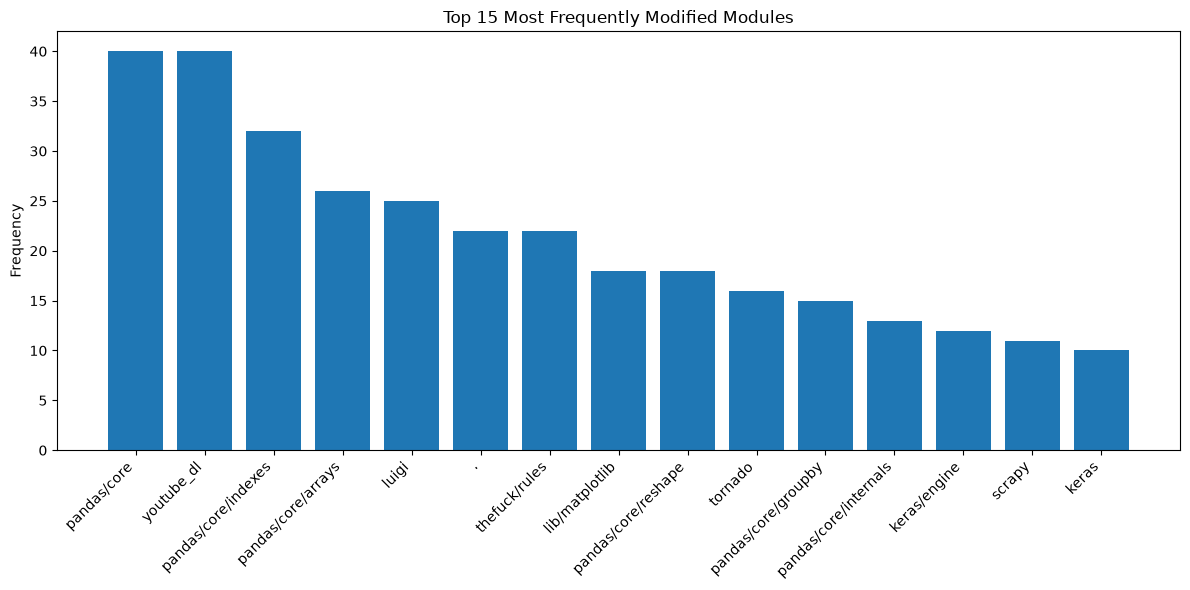

In [127]:
top_modules = (pd.Series(module_counts).sort_values(ascending=False).head(15))
plt.figure(figsize=(12,6))
bars=plt.bar(top_modules.index,top_modules.values)
plt.title("Top 15 Most Frequently Modified Modules")
plt.ylabel("Frequency")
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()


In [128]:
df_clean["modified_modules"] = df_clean["modified_modules"].apply(
    lambda modules: [
        "root" if module == "." else module
        for module in modules
    ]
)

module_counts= Counter( 
    module
    for module_list in df_clean["modified_modules"]
    for module in module_list
    )
module_counts

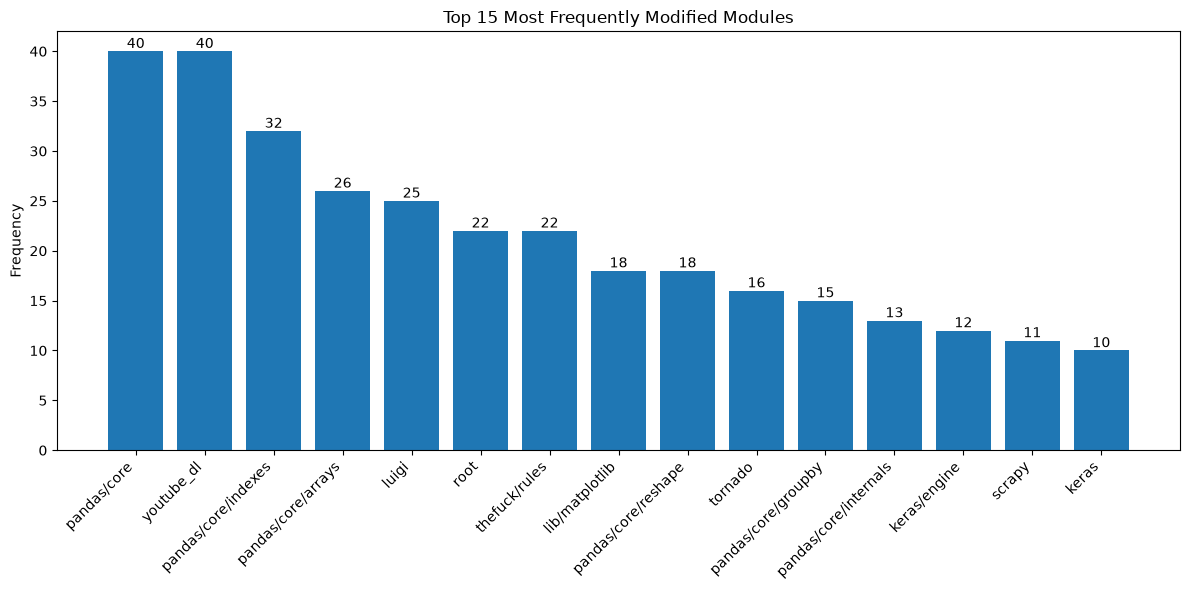

In [131]:
top_modules = (pd.Series(module_counts).sort_values(ascending=False).head(15))
plt.figure(figsize=(12,6))
bars=plt.bar(top_modules.index,top_modules.values)
plt.title("Top 15 Most Frequently Modified Modules")
plt.ylabel("Frequency")
plt.xticks(rotation = 45, ha="right")
plt.bar_label(bars)
plt.tight_layout()
plt.show()


Modules such as pandas/core, pandas/core/indexes, and pandas/core/arrays are among the most frequently modified components, suggesting that bug fixes are concentrated in the core implementation of several projects.

A relatively small number of modules account for a disproportionately large number of bug fixes, indicating that some components undergo maintenance more frequently than others.

Unlike file-level features, the engineered modified_modules feature captures subsystem-level information (e.g., pandas/core/groupby, keras/engine), providing higher-level semantic context that can support repository-aware retrieval.

The most frequently modified modules span several independent projects, including Pandas, Keras, Luigi, Tornado, and YouTube-DL, demonstrating that the dataset covers a diverse set of Python ecosystems rather than being dominated by a single repository

## Which exception types are most common in each repository?

In [137]:
exception_project = df_clean.explode("exception_types").reset_index(drop=True)
exception_project

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,has_comment,declared_classes_in_patch,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules,lines_changed
0,keras,32,3.7.3,a3d160b9467c99cbb27f9aa0382c759f45c8ee66,709f791af201caaab4aa180bda259989087cfe47,tests/keras/test_callbacks.py,diff --git a/keras/callbacks.py b/keras/callba...,NaN,{keras/callbacks.py},1,...,False,"{ReduceLROnPlateau,ReduceLROnPlateau,ReduceLRO...","{__init__,in_cooldown}",5,2,ValueError,1,[keras],1,17
1,keras,35,3.7.3,06eaeebecfb73c23bfd531013ca172ee3bf5069c,738819de0b7e6bc45abed8d0640f02b81c6ac4e9,tests/keras/preprocessing/image_test.py,diff --git a/keras/preprocessing/image.py b/ke...,NaN,{keras/preprocessing/image.py},1,...,True,"{ImageDataGenerator,NumpyArrayIterator,Directo...",{},3,0,ValueError,1,[keras/preprocessing],1,19
2,keras,34,3.7.3,7ef5244a2f1f7f7b76e3c804b82cbb20cdf4d139,4b74fc5418944c9f449eb88ed4b40ada280fa5ca,tests/test_multiprocessing.py,diff --git a/keras/engine/training.py b/keras/...,NaN,"{keras/engine/training.py,keras/utils/data_uti...",2,...,True,"{Model,Model,Model,Model,Sequence}",{__iter__},5,1,NaN,0,"[keras/engine, keras/utils]",2,26
3,keras,33,3.7.3,1c9a49781da2101507db23e2014e4e5d16bd2e52,70ad0d6e4a569701ef106058397ad0540ec08340,tests/keras/preprocessing/text_test.py,diff --git a/keras/preprocessing/text.py b/ker...,NaN,{keras/preprocessing/text.py},1,...,False,{},{text_to_word_sequence},0,1,NaN,0,[keras/preprocessing],1,17
4,keras,20,3.7.3,76da5f0a21ca98e4bf6706e182fb825243e76204,6dd087ab73b09e449144ff17450cc14f981b9ac2,tests/keras/layers/convolutional_test.py,diff --git a/keras/backend/cntk_backend.py b/k...,NaN,"{keras/backend/cntk_backend.py,keras/backend/t...",5,...,True,"{Conv2DTranspose,Conv2DTranspose,Conv2DTranspo...","{in_top_k,conv2d_transpose,conv2d_transpose,_p...",5,22,ValueError,1,"[keras/backend, keras/layers, keras/utils]",3,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,pandas,140,3.8.3,3b19e1d,4375daffeed16531bae3fdaf85324b590d1dcb59,pandas/tests/groupby/test_apply.py,diff --git a/pandas/core/groupby/generic.py b/...,NaN,{pandas/core/groupby/generic.py},1,...,True,{},{_recast_datetimelike_result},0,1,NaN,0,[pandas/core/groupby],1,4
584,pandas,14,3.8.3,e7b23d4,dd71064327721c1ec7366000f357b0c08bcec4d2,pandas/tests/arithmetic/test_datetime64.py;pan...,diff --git a/pandas/core/ops/dispatch.py b/pan...,NaN,"{pandas/core/ops/dispatch.py,pandas/tests/arit...",2,...,True,{},"{should_series_dispatch,id_func,names}",0,3,NaN,0,"[pandas/core/ops, pandas/tests/arithmetic]",2,18
585,pandas,22,3.8.3,38b669a,299e27da8a75d02d84870c1ca5971f4dd0f046e6,pandas/tests/window/test_base_indexer.py,diff --git a/pandas/core/window/common.py b/pa...,NaN,"{pandas/core/window/common.py,pandas/core/wind...",2,...,True,"{BASEINDEXER_WHITELIST,_Rolling_and_Expanding,...","{get_weighted_roll_func,validate_baseindexer_s...",4,4,NaN,0,[pandas/core/window],1,10
586,pandas,149,3.8.3,0d69d91,fa1364d1299a53093bc704f9c34c595b602a568b,pandas/tests/io/test_gcs.py,diff --git a/pandas/io/parquet.py b/pandas/io/...,NaN,{pandas/io/parquet.py},1,...,True,{FastParquetImpl},{get_engine},1,1,AbstractMethodError,1,[pandas/io],1,8


In [138]:
top10=exception_project["exception_types"].value_counts().head(10).index
top10

Index(['ValueError', 'TypeError', 'KeyError', 'NotImplementedError',
       'IndexError', 'ImportError', 'AttributeError', 'AbstractMethodError',
       'OverflowError', 'RuntimeError'],
      dtype='str', name='exception_types')

In [139]:
exception_project = exception_project[exception_project["exception_types"].isin(top10)]
cross = pd.crosstab(exception_project["project"],exception_project["exception_types"])
cross

exception_types,AbstractMethodError,AttributeError,ImportError,IndexError,KeyError,NotImplementedError,OverflowError,RuntimeError,TypeError,ValueError
project,,,,,,,,,,
ansible,0,0,1,0,0,0,0,0,1,1
black,0,0,0,1,0,1,0,0,0,3
cookiecutter,0,0,0,0,0,0,0,0,0,1
fastapi,0,0,2,0,0,0,0,0,0,1
keras,0,0,0,0,0,0,0,1,0,11
luigi,0,1,1,0,0,0,0,1,1,4
matplotlib,0,0,0,0,0,1,0,1,0,3
pandas,6,1,1,4,16,8,6,0,30,34
sanic,0,2,0,0,0,1,0,0,0,0


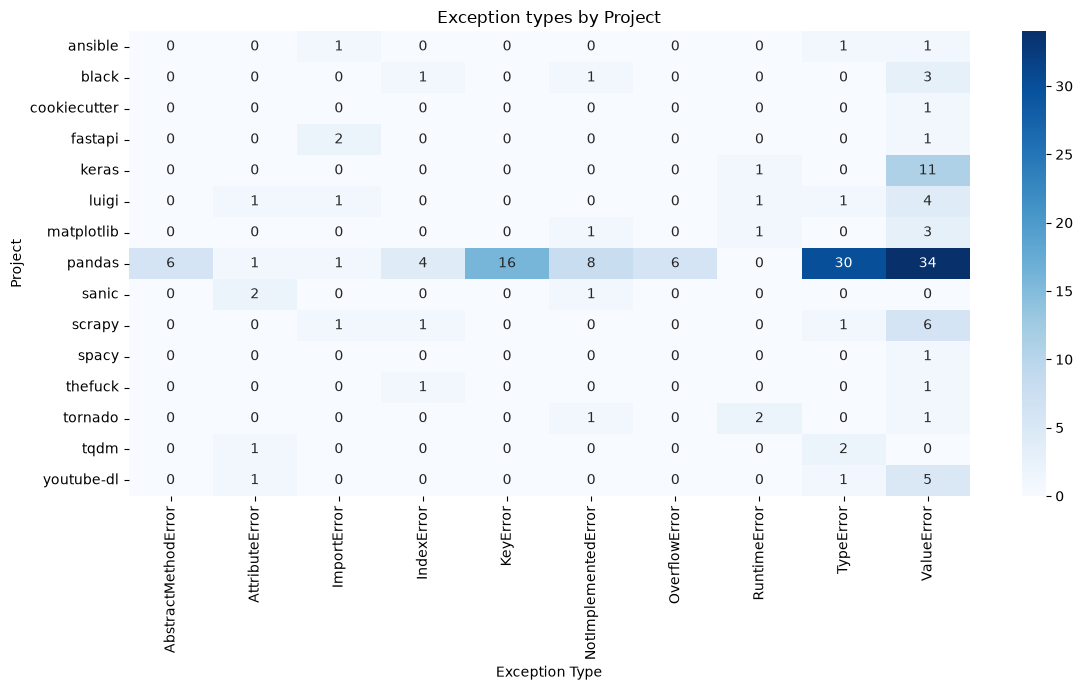

In [141]:
plt.figure(figsize=(12,7))
sns.heatmap(cross,annot=True,fmt="d",cmap="Blues")
plt.title("Exception types by Project")
plt.xlabel("Exception Type")
plt.ylabel("Project")

plt.tight_layout()
plt.show()

The most obvious observation is that Pandas contributes the majority of the occurrences for several common exception types.Many patches in the BugsInPy dataset involving these exception types originate from the Pandas project.

ValueError appears in many repositories, This indicates that ValueError is a broadly used built-in exception rather than being associated with a specific project.

Certain exception types appear almost exclusively in one repository.
* KeyError is almost entirely associated with Pandas in this dataset.
* OverflowError also appears only in Pandas among the top exceptions.
shows that some semantic features are repository-dependent.

This shows that exception types are not uniformly distributed across repositories. Combining repository information with extracted exception types may therefore improve repository-aware bug retrieval by narrowing the search space to semantically similar historical fixes.